<div style="
    padding: 20px;
    color: white;
    margin: 0;
    font-size: 300%;
    font-weight: 800;
    text-align: center;
    display: fill;
    border-radius: 60px;
    background-color: #D8CEF6;
    box-shadow: 0 4px 8px rgba(0, 0, 0, 0.2);
    text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.5);
">
    Deep Learning-based Classification for Clothing  <br>
</div>

# <div style="display: inline-block; padding: 20px 20px; border-radius: 15px; background: linear-gradient(135deg, #d8bfd8, #8b008b); box-shadow: 3px 3px 8px rgba(0, 0, 0, 0.2); font-size: 35px; font-family: Arial, sans-serif; color: #ffffff; text-align: center;">Import Libraries & Read Dataset</div>

In [1]:
# Model Analysis and Visualization Tools
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import xml.etree.ElementTree as ET
import os
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# Model Design
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, LeakyReLU, ReLU, Flatten, GlobalAveragePooling2D, Input
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

import os
import numpy as np
from PIL import Image

2026-02-03 08:14:23.793902: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770106463.980778      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770106464.035774      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770106464.483531      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770106464.483567      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770106464.483570      24 computation_placer.cc:177] computation placer alr

In [2]:
os.environ['TF_XLA_FLAGS'] = '--tf_xla_enable_xla_devices=false'

In [3]:
dataset_path = "/kaggle/input/e-commerce-mens-clothing-dataset/dataset_clean"

folders = [f for f in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, f))]
print(folders)

['men_cargos', 'formal_pants', 'casual_shirts', 'printed_hoodies', 'solid_tshirts', 'printed_tshirts', 'jeans', 'formal_shirts']


In [4]:
classes = {'men_cargos': 0, 'formal_pants': 1, 'casual_shirts': 2, 'printed_hoodies': 3, 
           'solid_tshirts': 4, 'printed_tshirts': 5, 'jeans': 6, 'formal_shirts': 7}

image_data = []
labels = []

for class_name, label in classes.items():
    class_folder = os.path.join(dataset_path, class_name)
    for image_file in os.listdir(class_folder):
        image_path = os.path.join(class_folder, image_file)

        try:
            img = Image.open(image_path).convert("RGB")  
            img = img.resize((128, 128))  
            image_data.append(np.array(img))
            labels.append(label)
        except Exception as e:
            print(f"error path: {image_path}, error: {e}")

X = np.array(image_data)
y = np.array(labels)

print("Label Distribution:", dict(zip(*np.unique(y, return_counts=True))))

Label Distribution: {np.int64(0): np.int64(1137), np.int64(1): np.int64(986), np.int64(2): np.int64(1182), np.int64(3): np.int64(1056), np.int64(4): np.int64(1040), np.int64(5): np.int64(1097), np.int64(6): np.int64(1135), np.int64(7): np.int64(992)}


In [5]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y),
    y=y
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(0.9482189973614775), 1: np.float64(1.0934330628803246), 2: np.float64(0.9121192893401016), 3: np.float64(1.0209517045454546), 4: np.float64(1.0366586538461537), 5: np.float64(0.9827939835916135), 6: np.float64(0.9498898678414097), 7: np.float64(1.086819556451613)}


In [6]:
X_normalized = X / 255.0

X_train, X_test, y_train, y_test = train_test_split(X_normalized, y, test_size=0.4, random_state=42)

print(f"Training data shape: {X_train.shape}, Training labels shape: {y_train.shape}")
print(f"Testing data shape: {X_test.shape}, Testing labels shape: {y_test.shape}")

Training data shape: (5175, 128, 128, 3), Training labels shape: (5175,)
Testing data shape: (3450, 128, 128, 3), Testing labels shape: (3450,)


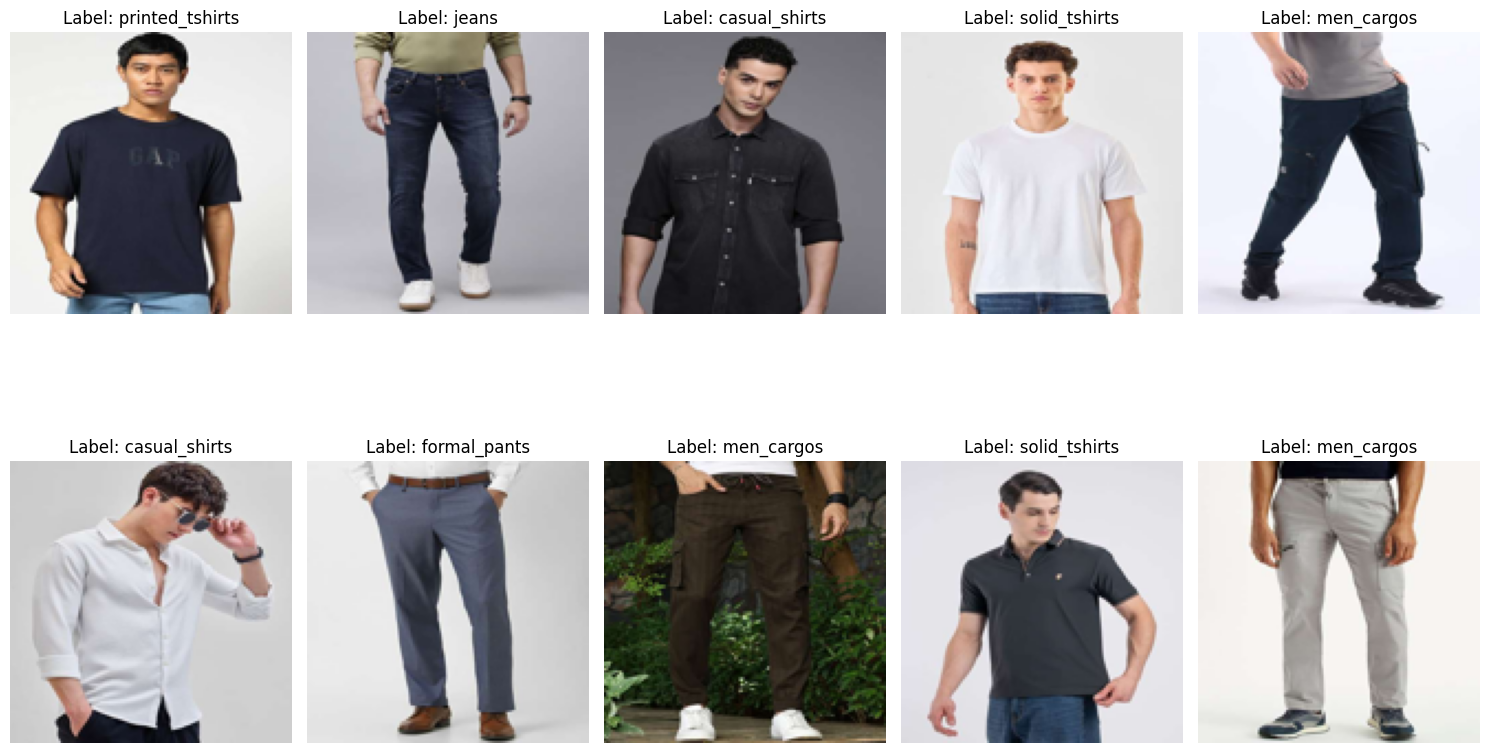

In [7]:
idx_to_class = {v: k for k, v in classes.items()}

def visualize_images(X, y, num_images=10):
    plt.figure(figsize=(15, 10))
    indices = random.sample(range(len(X)), num_images)

    for i, idx in enumerate(indices):
        image = X[idx].reshape(128, 128, 3)  
        label_index = y[idx]
        label = idx_to_class[label_index]  

        plt.subplot(2, 5, i + 1)
        plt.imshow(image.astype('uint8')) 
        plt.title(f'Label: {label}')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

visualize_images(X, y, num_images=10)

In [8]:
def plot_history(history, main_title):
    plt.figure(figsize=(12, 5))

    plt.suptitle(main_title, fontsize=20, fontweight='bold')

    plt.subplot(1, 2, 1)
    plt.plot(history['accuracy'], label='Training Accuracy')
    plt.plot(history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy', fontsize=16)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history['loss'], label='Training Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.title('Loss', fontsize=16)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend()

    plt.tight_layout(rect=[0, 0, 1, 0.92])  
    plt.show()

early_stopping = EarlyStopping(
    monitor='val_loss',   
    patience=15,           
    restore_best_weights=True  
)

# <div style="display: inline-block; padding: 20px 20px; border-radius: 15px; background: linear-gradient(135deg, #d8bfd8, #8b008b); box-shadow: 3px 3px 8px rgba(0, 0, 0, 0.2); font-size: 35px; font-family: Arial, sans-serif; color: #ffffff; text-align: center;">Neural Network</div>

In [9]:
model_single = Sequential([
    Input(shape=(128,128,3)),
    Flatten(),
    Dense(128, activation='relu'),   
    Dense(8, activation='softmax')   
])

model_single.compile(
    optimizer='rmsprop',
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

model_single.summary()

hist = model_single.fit(
    X_train, y_train,
    epochs=50,
    batch_size=8,
    validation_data=(X_test, y_test),
    class_weight=class_weights,      
    callbacks=[early_stopping]
)

I0000 00:00:1770106567.031242      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1770106567.036999      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 49152)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,291,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,292,616 (24.00 MB)

 Trainable params: 6,292,616 (24.00 MB)

...

Epoch 1/50


I0000 00:00:1770106571.671979      73 service.cc:152] XLA service 0x7a3934007690 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1770106571.672021      73 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1770106571.672041      73 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1770106571.837427      73 cuda_dnn.cc:529] Loaded cuDNN version 91002


 54/647 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1532 - loss: 54.5792

I0000 00:00:1770106572.723660      73 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


647/647 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.1878 - loss: 19.6816 - val_accuracy: 0.2067 - val_loss: 1.9028
Epoch 2/50
647/647 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2052 - loss: 1.9201 - val_accuracy: 0.2038 - val_loss: 1.8269
Epoch 3/50
647/647 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2019 - loss: 1.9213 - val_accuracy: 0.2078 - val_loss: 1.8397
Epoch 4/50
647/647 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2018 - loss: 1.8988 - val_accuracy: 0.2035 - val_loss: 1.7975
Epoch 5/50
647/647 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2016 - loss: 1.8537 - val_accuracy: 0.1962 - val_loss: 1.8229
Epoch 6/50
647/647 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2180 - loss: 1.8467 - val_accuracy: 0.1928 - val_loss: 1.8162
Epoch 7/50
647/647 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.1892 - loss: 1.8978 - val_accuracy: 0.2070 - val_loss: 1.9731
Epoch 8/50
647/647 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2218 - loss: 1.8439 - val_accuracy: 0.1890 - val

108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Accuracy: 0.2035


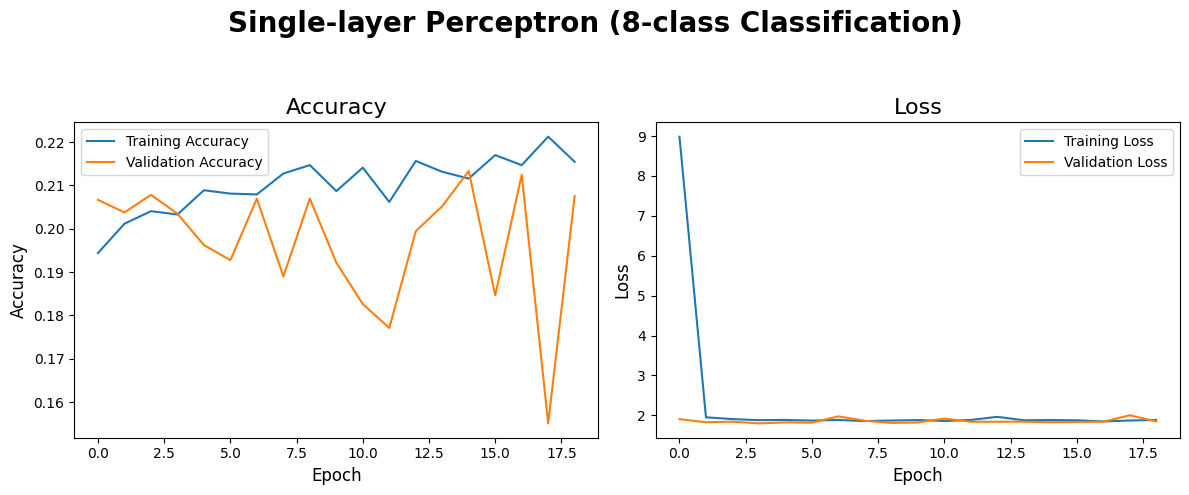

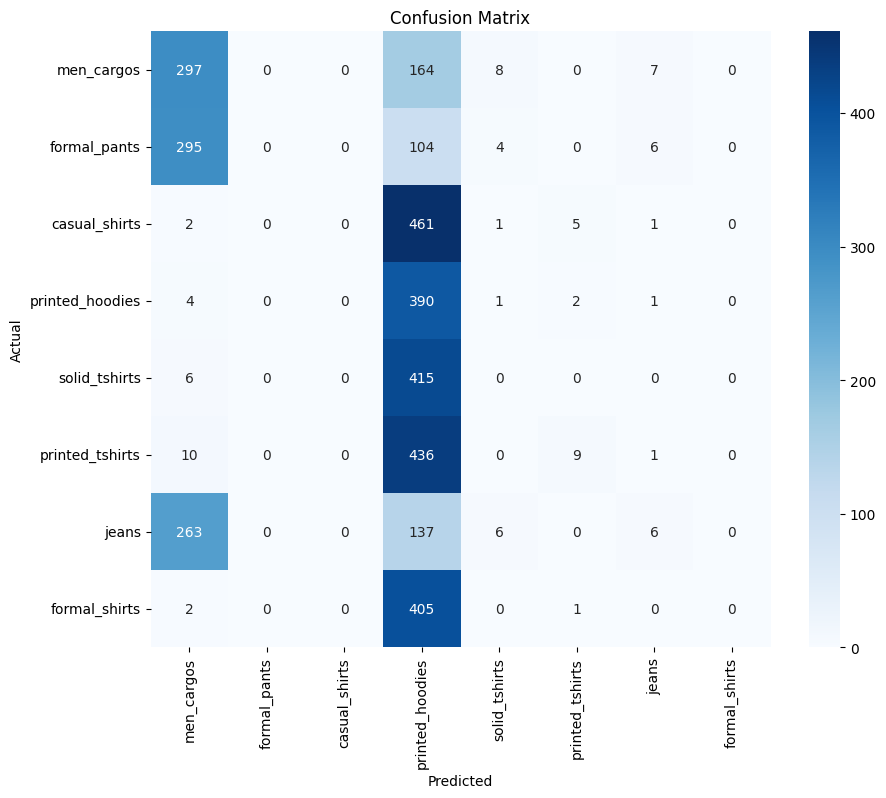

In [10]:
y_pred_prob = model_single.predict(X_test)
y_pred_classes = np.argmax(y_pred_prob, axis=1) 

accuracy = accuracy_score(y_test, y_pred_classes)
print(f"Accuracy: {accuracy:.4f}")

plot_history(hist.history, "Single-layer Perceptron (8-class Classification)")

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[idx_to_class[i] for i in range(8)],
            yticklabels=[idx_to_class[i] for i in range(8)])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [11]:
model_dnn = Sequential([
    Input(shape=(128,128,3)),
    Flatten(),                     
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dense(8, activation='softmax') 
])

model_dnn.compile(
    optimizer='adam',                             
    loss='sparse_categorical_crossentropy',     
    metrics=['accuracy']
)

model_dnn.summary()

hist = model_dnn.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,              
    class_weight=class_weights, 
    callbacks=[early_stopping]
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 49152)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │    25,166,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,335,176 (96.65 MB)

 Trainable params: 25,333,384 (96.64 MB)

 Non-trainable params: 1,792 (7.00 KB)

Epoch 1/50
162/162 ━━━━━━━━━━━━━━━━━━━━ 12s 44ms/step - accuracy: 0.2675 - loss: 2.0798 - val_accuracy: 0.3470 - val_loss: 1.7013
Epoch 2/50
162/162 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.3891 - loss: 1.5535 - val_accuracy: 0.3733 - val_loss: 1.6907
Epoch 3/50
162/162 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.4223 - loss: 1.4469 - val_accuracy: 0.3612 - val_loss: 1.7923
Epoch 4/50
162/162 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.4633 - loss: 1.3584 - val_accuracy: 0.3107 - val_loss: 1.8219
Epoch 5/50
162/162 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.4738 - loss: 1.3585 - val_accuracy: 0.1670 - val_loss: 3.0652
Epoch 6/50
162/162 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.4965 - loss: 1.2904 - val_accuracy: 0.3838 - val_loss: 1.5297
Epoch 7/50
162/162 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5009 - loss: 1.2592 - val_accuracy: 0.4365 - val_loss: 1.4397
Epoch 8/50
162/162 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5087 - loss: 1.2359 - val_acc

108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Accuracy: 0.5371


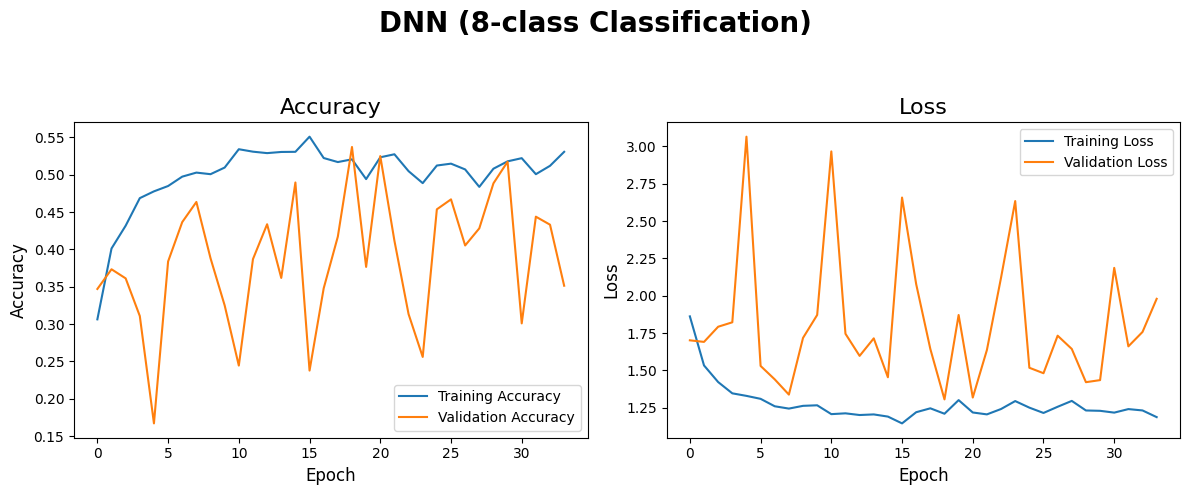

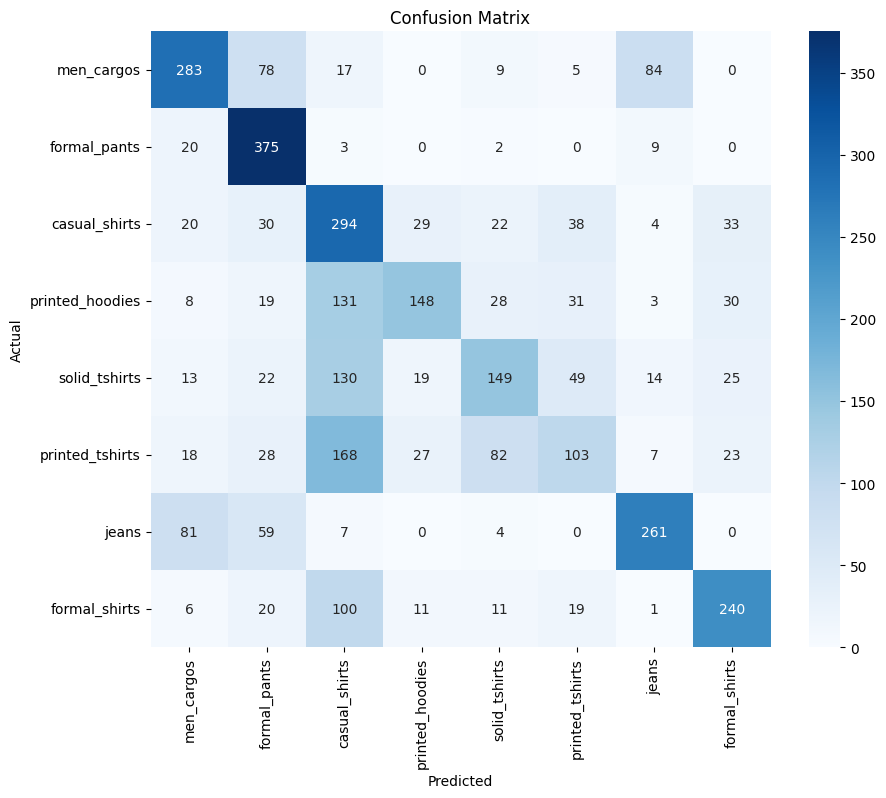

In [12]:
y_pred_prob = model_dnn.predict(X_test)
y_pred_classes = np.argmax(y_pred_prob, axis=1) 

accuracy = accuracy_score(y_test, y_pred_classes)
print(f"Accuracy: {accuracy:.4f}")

plot_history(hist.history, "DNN (8-class Classification)")

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[idx_to_class[i] for i in range(8)],
            yticklabels=[idx_to_class[i] for i in range(8)])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [13]:
model_cnn = Sequential([
    Input(shape=(128,128,3)),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(8, activation='softmax')
])

model_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_cnn.summary()

hist = model_cnn.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stopping]
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     8,388,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,409,160 (32.08 MB)

 Trainable params: 8,409,160 (32.08 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
162/162 ━━━━━━━━━━━━━━━━━━━━ 12s 50ms/step - accuracy: 0.3334 - loss: 1.8406 - val_accuracy: 0.5858 - val_loss: 1.1040
Epoch 2/50
162/162 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.6637 - loss: 0.8765 - val_accuracy: 0.6383 - val_loss: 0.9851
Epoch 3/50
162/162 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.7891 - loss: 0.5874 - val_accuracy: 0.6554 - val_loss: 0.9788
Epoch 4/50
162/162 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.8892 - loss: 0.3307 - val_accuracy: 0.6423 - val_loss: 1.1127
Epoch 5/50
162/162 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9429 - loss: 0.1825 - val_accuracy: 0.6551 - val_loss: 1.4604
Epoch 6/50
162/162 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9602 - loss: 0.1188 - val_accuracy: 0.6438 - val_loss: 1.5124
Epoch 7/50
162/162 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9871 - loss: 0.0510 - val_accuracy: 0.6617 - val_loss: 1.6800
Epoch 8/50
162/162 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9907 - loss: 0.0348 - val_acc

108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
Accuracy: 0.6554


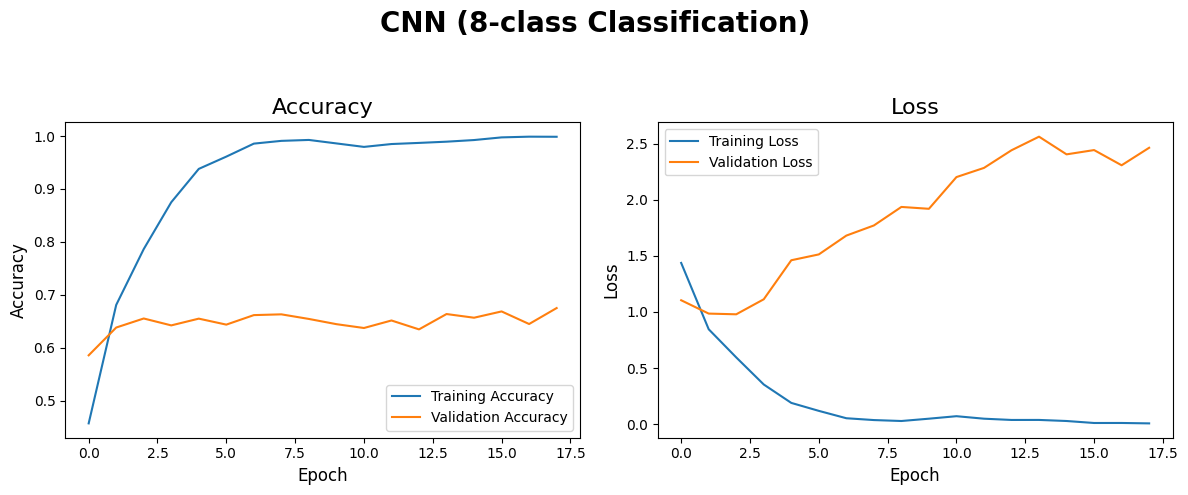

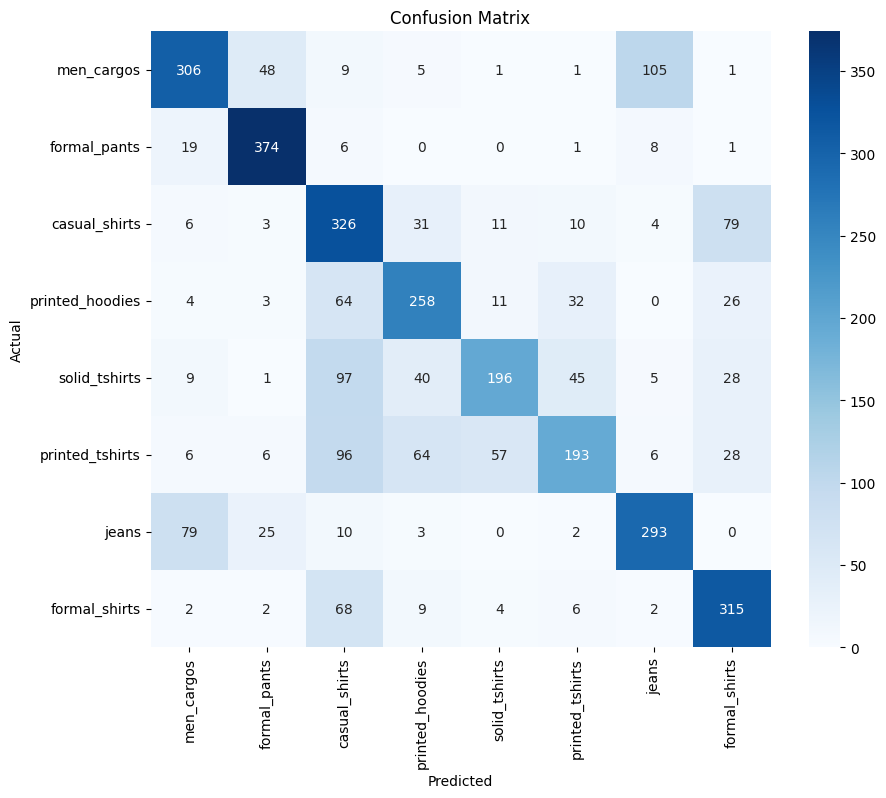

In [14]:
y_pred_prob = model_cnn.predict(X_test)
y_pred_classes = np.argmax(y_pred_prob, axis=1) 

accuracy = accuracy_score(y_test, y_pred_classes)
print(f"Accuracy: {accuracy:.4f}")

plot_history(hist.history, "CNN (8-class Classification)")

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[idx_to_class[i] for i in range(8)],
            yticklabels=[idx_to_class[i] for i in range(8)])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# <div style="display: inline-block; padding: 20px 20px; border-radius: 15px; background: linear-gradient(135deg, #d8bfd8, #8b008b); box-shadow: 3px 3px 8px rgba(0, 0, 0, 0.2); font-size: 35px; font-family: Arial, sans-serif; color: #ffffff; text-align: center;">Transfer Leaning</div>

In [15]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(128,128,3))
base_model.trainable = False  

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(8, activation='softmax')(x)  

v2_model = Model(inputs=base_model.input, outputs=predictions)

v2_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',  
    metrics=['accuracy']
)

v2_model.summary()

hist = v2_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=16,
    class_weight=class_weights,  
    callbacks=[early_stopping]
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 2,422,984 (9.24 MB)

 Trainable params: 165,000 (644.53 KB)

...

321/324 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2797 - loss: 1.9330

2026-02-03 08:20:10.983114: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-03 08:20:11.119530: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


324/324 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.2807 - loss: 1.9297

2026-02-03 08:20:27.610682: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-03 08:20:27.746678: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


324/324 ━━━━━━━━━━━━━━━━━━━━ 43s 88ms/step - accuracy: 0.2810 - loss: 1.9286 - val_accuracy: 0.6475 - val_loss: 1.0138
Epoch 2/50
324/324 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.5871 - loss: 1.0898 - val_accuracy: 0.7200 - val_loss: 0.7730
Epoch 3/50
324/324 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.6454 - loss: 0.9098 - val_accuracy: 0.7368 - val_loss: 0.7017
Epoch 4/50
324/324 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.6887 - loss: 0.8101 - val_accuracy: 0.7545 - val_loss: 0.6505
Epoch 5/50
324/324 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7181 - loss: 0.7397 - val_accuracy: 0.7643 - val_loss: 0.6215
Epoch 6/50
324/324 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7404 - loss: 0.6755 - val_accuracy: 0.7710 - val_loss: 0.6032
Epoch 7/50
324/324 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7499 - loss: 0.6637 - val_accuracy: 0.7774 - val_loss: 0.5872
Epoch 8/50
324/324 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7537 - loss: 0.6331 - val_accuracy: 0.78

2026-02-03 08:23:25.268073: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-03 08:23:25.405704: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


107/108 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

2026-02-03 08:23:36.089662: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-03 08:23:36.228312: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-03 08:23:36.364955: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


108/108 ━━━━━━━━━━━━━━━━━━━━ 21s 102ms/step
Accuracy: 0.8116


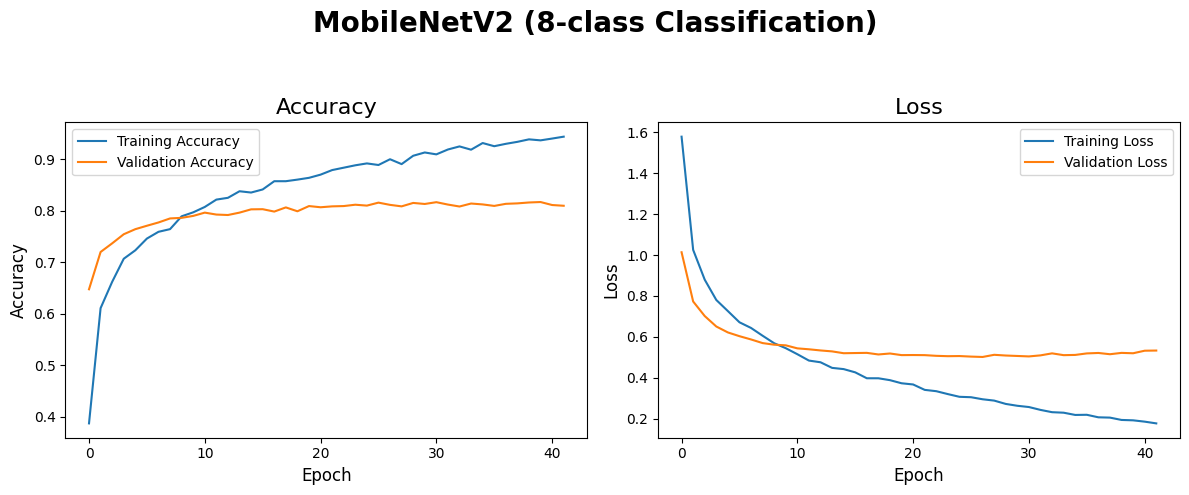

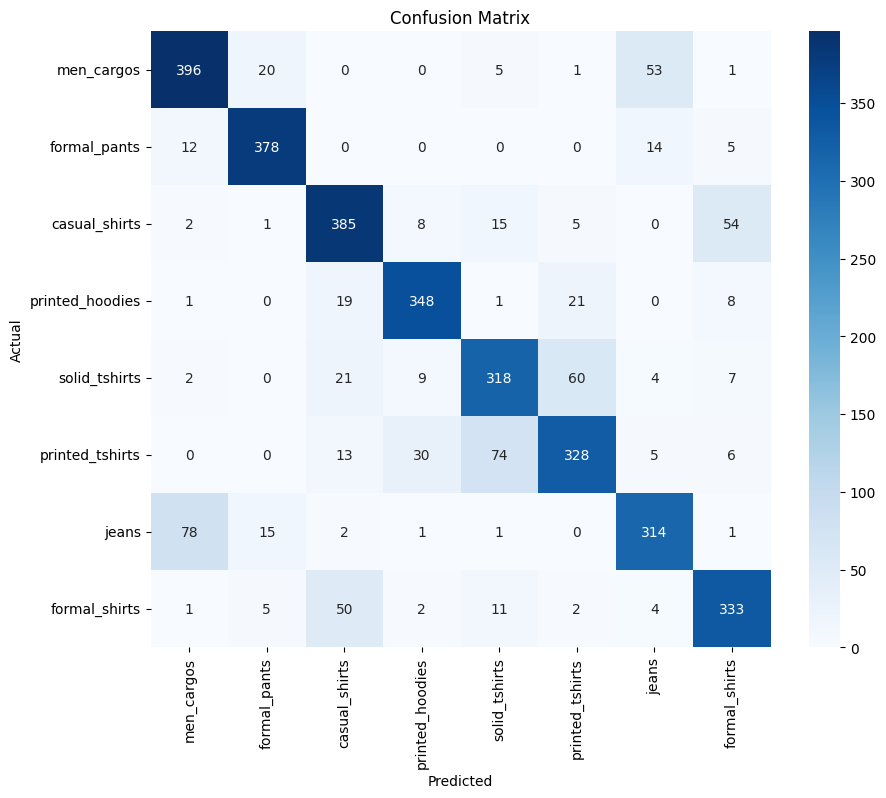

In [16]:
y_pred_prob = v2_model.predict(X_test)
y_pred_classes = np.argmax(y_pred_prob, axis=1)  

accuracy = accuracy_score(y_test, y_pred_classes)
print(f"Accuracy: {accuracy:.4f}")

plot_history(hist.history, "MobileNetV2 (8-class Classification)")

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[idx_to_class[i] for i in range(8)],
            yticklabels=[idx_to_class[i] for i in range(8)])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [17]:
from tensorflow.keras.applications import MobileNetV3Small

base_model = MobileNetV3Small(weights='imagenet', include_top=False, input_shape=(128,128,3))
base_model.trainable = False  

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(8, activation='softmax')(x)  

v3_model = Model(inputs=base_model.input, outputs=predictions)

v3_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',  
    metrics=['accuracy']
)

v3_model.summary()

hist = v3_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=16,
    class_weight=class_weights,  
    callbacks=[early_stopping]
)

/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:452: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 128, 128,  │          0 │ input_layer_4[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv (Conv2D)       │ (None, 64, 64,    │        432 │ rescaling[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_bn             │ (None, 64, 64,    │         64 │ conv[0][0]        │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 64, 64,    │          0 │ conv_bn[0][0]     │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 65, 65,    │          0 │ activation[0][0]  │
│ (ZeroPadding2D)     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 32, 32,    │        144 │ expanded_conv_de… │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 32, 32,    │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 32, 32,    │          0 │ expanded_conv_de… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 16)  │          0 │ re_lu[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 8)   │        136 │ expanded_conv_sq… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 8)   │          0 │ expanded_conv_sq… │
│ (ReLU)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 16)  │        144 │ expanded_conv_sq… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1, 1, 16)  │          0 │ expanded_conv_sq… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 1, 1, 16)  │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 1, 1, 16)  │          0 │ re_lu_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 32, 32,    │          0 │ re_lu[0][0],      │
│ (Multiply)          │ 16)               │            │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 32, 32,    │        256 │ expanded_conv_sq

 Total params: 1,014,008 (3.87 MB)

 Trainable params: 74,888 (292.53 KB)

 Non-trainable params: 939,120 (3.58 MB)

Epoch 1/50
324/324 ━━━━━━━━━━━━━━━━━━━━ 31s 63ms/step - accuracy: 0.1379 - loss: 2.1615 - val_accuracy: 0.1800 - val_loss: 2.0696
Epoch 2/50
324/324 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.1354 - loss: 2.0874 - val_accuracy: 0.2281 - val_loss: 2.0586
Epoch 3/50
324/324 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.1581 - loss: 2.0565 - val_accuracy: 0.2365 - val_loss: 2.0520
Epoch 4/50
324/324 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.1910 - loss: 2.0434 - val_accuracy: 0.1878 - val_loss: 2.0391
Epoch 5/50
324/324 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.1882 - loss: 2.0366 - val_accuracy: 0.1730 - val_loss: 2.0231
Epoch 6/50
324/324 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.1930 - loss: 2.0176 - val_accuracy: 0.2345 - val_loss: 2.0101
Epoch 7/50
324/324 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.2024 - loss: 2.0062 - val_accuracy: 0.2319 - val_loss: 1.9950
Epoch 8/50
324/324 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.2095 - loss: 1.9929 - val_accuracy:

108/108 ━━━━━━━━━━━━━━━━━━━━ 13s 65ms/step
Accuracy: 0.3371


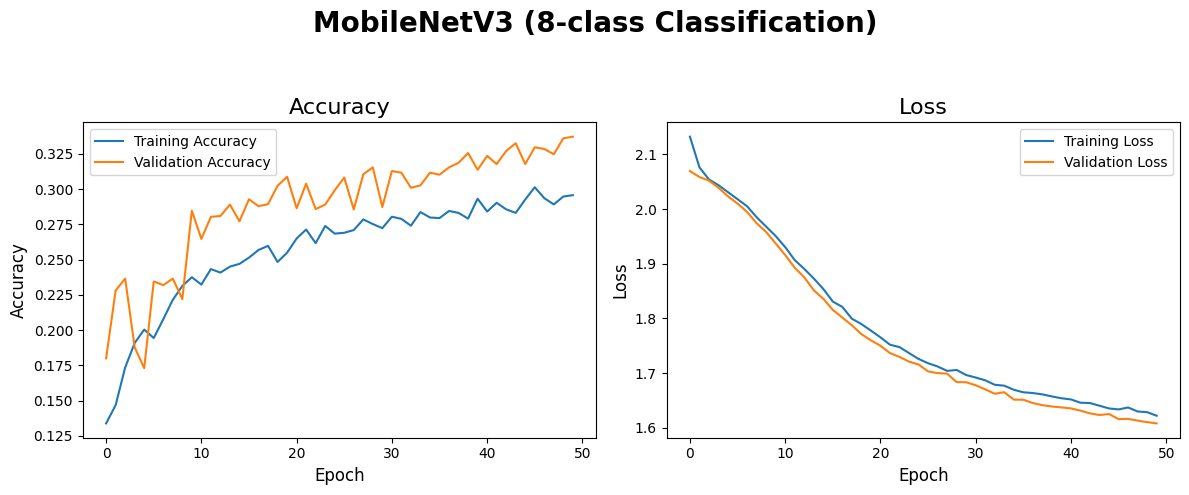

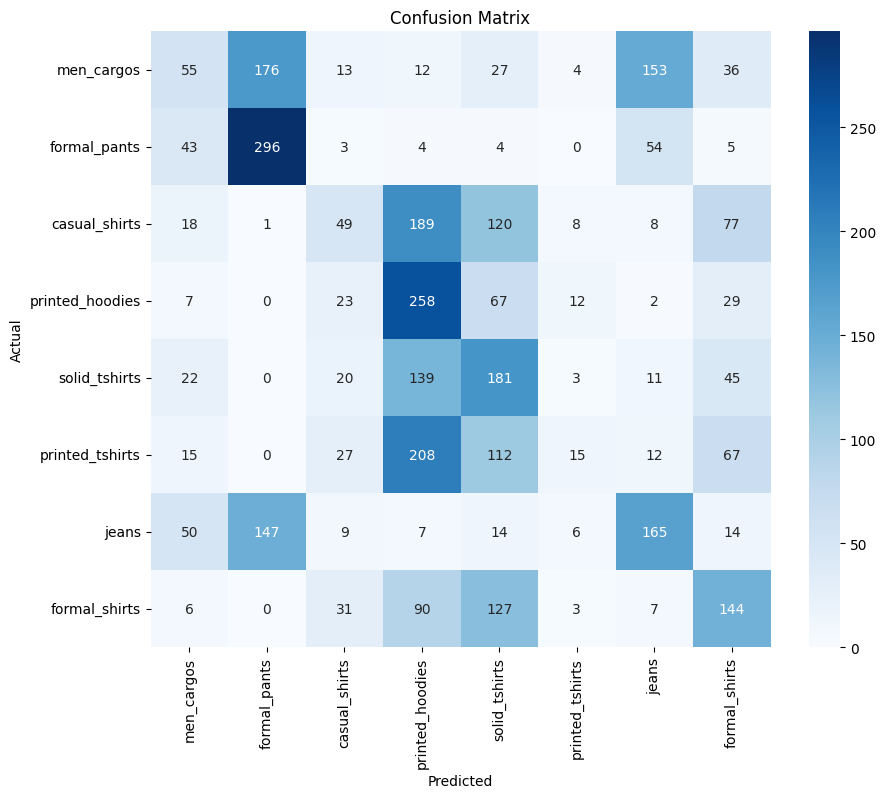

In [18]:
y_pred_prob = v3_model.predict(X_test)
y_pred_classes = np.argmax(y_pred_prob, axis=1)  

accuracy = accuracy_score(y_test, y_pred_classes)
print(f"Accuracy: {accuracy:.4f}")

plot_history(hist.history, "MobileNetV3 (8-class Classification)")

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[idx_to_class[i] for i in range(8)],
            yticklabels=[idx_to_class[i] for i in range(8)])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [19]:
from tensorflow.keras.applications import ResNet50

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(128,128,3))
base_model.trainable = False  

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(8, activation='softmax')(x)  

ResNet50_model = Model(inputs=base_model.input, outputs=predictions)

ResNet50_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',  
    metrics=['accuracy']
)

ResNet50_model.summary()

hist = ResNet50_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=16,
    class_weight=class_weights,  
    callbacks=[early_stopping]
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 134, 134,  │          0 │ input_layer_5[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 64,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 64,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 66, 66,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 32, 32,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 32, 32,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 32, 32,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 32, 32,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 32, 32,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_3_c

 Total params: 23,851,016 (90.98 MB)

 Trainable params: 263,304 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/50
324/324 ━━━━━━━━━━━━━━━━━━━━ 32s 68ms/step - accuracy: 0.1392 - loss: 2.2347 - val_accuracy: 0.1814 - val_loss: 2.0270
Epoch 2/50
324/324 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.1727 - loss: 2.0544 - val_accuracy: 0.3041 - val_loss: 1.9735
Epoch 3/50
324/324 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.2154 - loss: 1.9843 - val_accuracy: 0.3246 - val_loss: 1.9236
Epoch 4/50
324/324 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.2534 - loss: 1.9271 - val_accuracy: 0.3412 - val_loss: 1.8748
Epoch 5/50
324/324 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.2750 - loss: 1.8803 - val_accuracy: 0.3339 - val_loss: 1.8320
Epoch 6/50
324/324 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.2661 - loss: 1.8442 - val_accuracy: 0.3649 - val_loss: 1.7925
Epoch 7/50
324/324 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.2892 - loss: 1.8098 - val_accuracy: 0.3458 - val_loss: 1.7567
Epoch 8/50
324/324 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.2898 - loss: 1.7765 - 

108/108 ━━━━━━━━━━━━━━━━━━━━ 12s 71ms/step
Accuracy: 0.4707


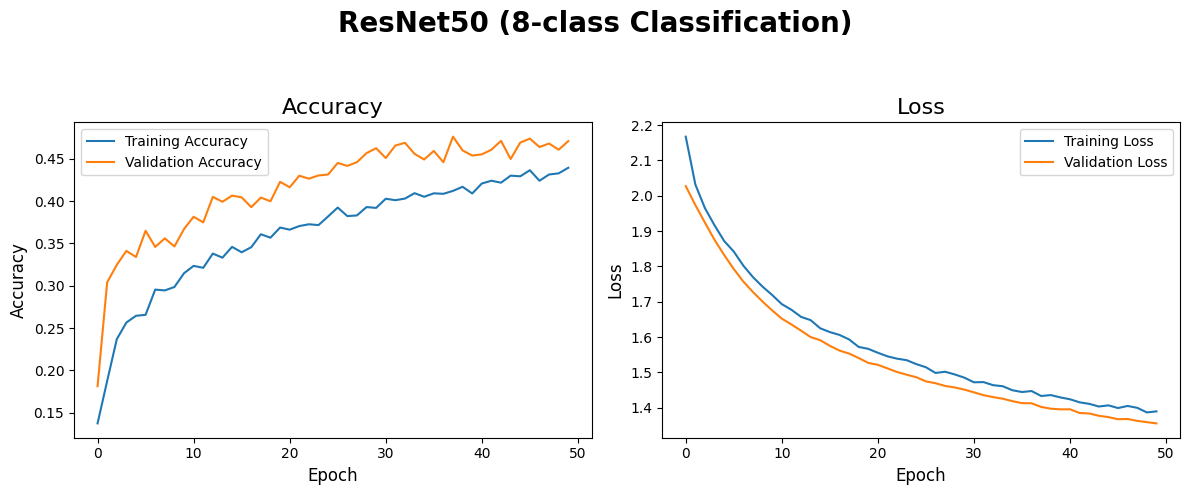

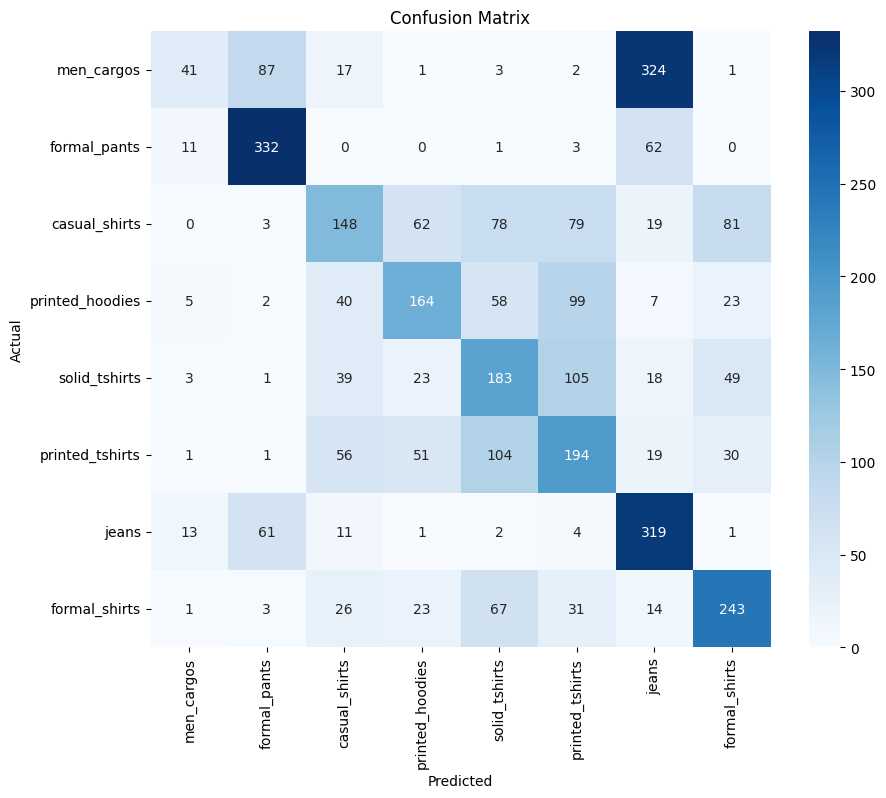

In [20]:
y_pred_prob = ResNet50_model.predict(X_test)
y_pred_classes = np.argmax(y_pred_prob, axis=1)  

accuracy = accuracy_score(y_test, y_pred_classes)
print(f"Accuracy: {accuracy:.4f}")

plot_history(hist.history, "ResNet50 (8-class Classification)")

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[idx_to_class[i] for i in range(8)],
            yticklabels=[idx_to_class[i] for i in range(8)])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [21]:
from tensorflow.keras.applications import VGG16

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(128,128,3))
base_model.trainable = False  

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(8, activation='softmax')(x)  

VGG16_model = Model(inputs=base_model.input, outputs=predictions)

VGG16_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',  
    metrics=['accuracy']
)

VGG16_model.summary()

hist = VGG16_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=16,
    class_weight=class_weights,  
    callbacks=[early_stopping]
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,781,384 (56.39 MB)

 Trainable params: 66,696 (260.53 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/50
324/324 ━━━━━━━━━━━━━━━━━━━━ 33s 83ms/step - accuracy: 0.1578 - loss: 2.2484 - val_accuracy: 0.4461 - val_loss: 1.7783
Epoch 2/50
324/324 ━━━━━━━━━━━━━━━━━━━━ 18s 56ms/step - accuracy: 0.3118 - loss: 1.7935 - val_accuracy: 0.5046 - val_loss: 1.5333
Epoch 3/50
324/324 ━━━━━━━━━━━━━━━━━━━━ 18s 55ms/step - accuracy: 0.4148 - loss: 1.5558 - val_accuracy: 0.5786 - val_loss: 1.3869
Epoch 4/50
324/324 ━━━━━━━━━━━━━━━━━━━━ 18s 55ms/step - accuracy: 0.4523 - loss: 1.4244 - val_accuracy: 0.5916 - val_loss: 1.2895
Epoch 5/50
324/324 ━━━━━━━━━━━━━━━━━━━━ 18s 55ms/step - accuracy: 0.4899 - loss: 1.3343 - val_accuracy: 0.6003 - val_loss: 1.2258
Epoch 6/50
324/324 ━━━━━━━━━━━━━━━━━━━━ 18s 56ms/step - accuracy: 0.5044 - loss: 1.2839 - val_accuracy: 0.6188 - val_loss: 1.1646
Epoch 7/50
324/324 ━━━━━━━━━━━━━━━━━━━━ 18s 55ms/step - accuracy: 0.5278 - loss: 1.2313 - val_accuracy: 0.6304 - val_loss: 1.1230
Epoch 8/50
324/324 ━━━━━━━━━━━━━━━━━━━━ 18s 55ms/step - accuracy: 0.5343 - loss: 1.1914 - 

108/108 ━━━━━━━━━━━━━━━━━━━━ 18s 113ms/step
Accuracy: 0.7249


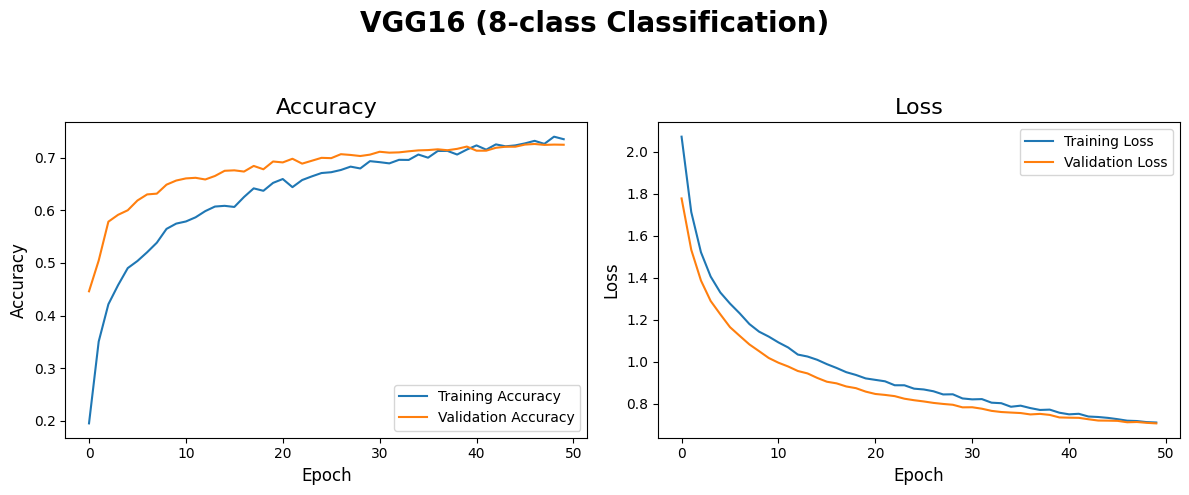

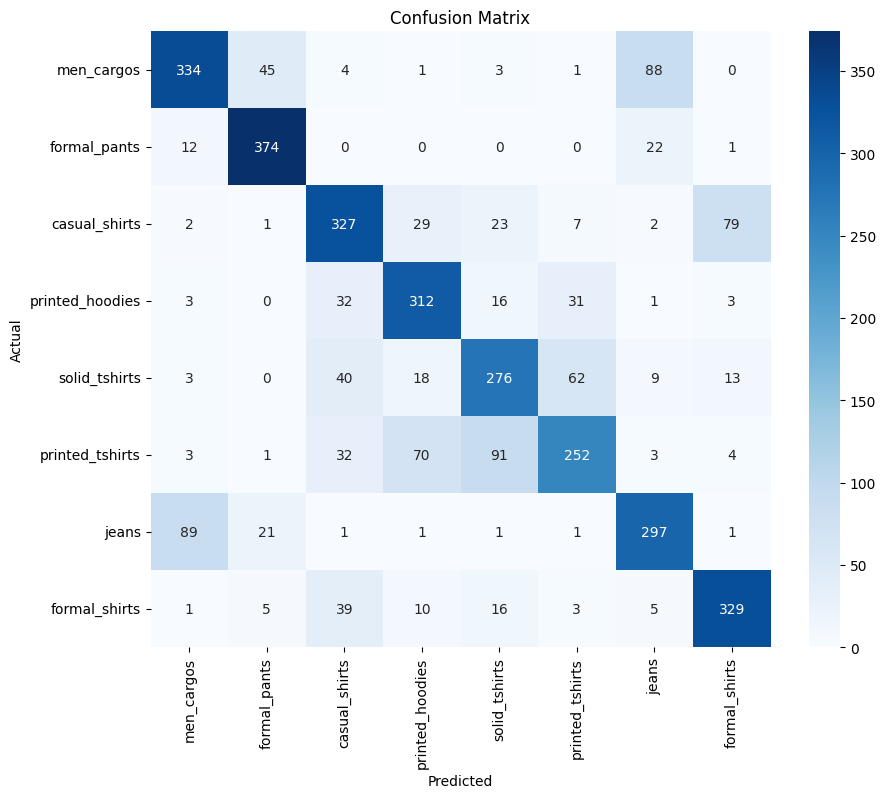

In [22]:
y_pred_prob = VGG16_model.predict(X_test)
y_pred_classes = np.argmax(y_pred_prob, axis=1)  

accuracy = accuracy_score(y_test, y_pred_classes)
print(f"Accuracy: {accuracy:.4f}")

plot_history(hist.history, "VGG16 (8-class Classification)")

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[idx_to_class[i] for i in range(8)],
            yticklabels=[idx_to_class[i] for i in range(8)])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [23]:
from tensorflow.keras.applications import InceptionV3

base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(128,128,3))
base_model.trainable = False  

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(8, activation='softmax')(x)  

InceptionV3_model = Model(inputs=base_model.input, outputs=predictions)

InceptionV3_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',  
    metrics=['accuracy']
)

InceptionV3_model.summary()

hist = InceptionV3_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=16,
    class_weight=class_weights,  
    callbacks=[early_stopping]
)

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 63, 63,    │        864 │ input_layer_7[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 63, 63,    │         96 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_18       │ (None, 63, 63,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 61, 61,    │      9,216 │ activation_18[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 61, 61,    │         96 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_19       │ (None, 61, 61,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 61, 61,    │     18,432 │ activation_19[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 61, 61,    │        192 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_20       │ (None, 61, 61,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 30, 30,    │          0 │ activation_20[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 30, 30,    │      5,120 │ max_pooling2d_2[… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 30, 30,    │        240 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_21       │ (None, 30, 30,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 28, 28,    │    138,240 │ activation_21[0]… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        576 │ conv2d_6[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_22       │ (None, 28, 28,    │          0 │ batch_normalizat

 Total params: 22,066,088 (84.18 MB)

 Trainable params: 263,304 (1.00 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

Epoch 1/50
324/324 ━━━━━━━━━━━━━━━━━━━━ 40s 83ms/step - accuracy: 0.3058 - loss: 2.1674 - val_accuracy: 0.5948 - val_loss: 1.0752
Epoch 2/50
324/324 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.5458 - loss: 1.2003 - val_accuracy: 0.6481 - val_loss: 0.9031
Epoch 3/50
324/324 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.5911 - loss: 1.0509 - val_accuracy: 0.6707 - val_loss: 0.8471
Epoch 4/50
324/324 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.6416 - loss: 0.9272 - val_accuracy: 0.6835 - val_loss: 0.8099
Epoch 5/50
324/324 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.6719 - loss: 0.8482 - val_accuracy: 0.6957 - val_loss: 0.7696
Epoch 6/50
324/324 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.6994 - loss: 0.7930 - val_accuracy: 0.7046 - val_loss: 0.7580
Epoch 7/50
324/324 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.6963 - loss: 0.7889 - val_accuracy: 0.7061 - val_loss: 0.7456
Epoch 8/50
324/324 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.7341 - loss: 0.7096 - val_acc

108/108 ━━━━━━━━━━━━━━━━━━━━ 17s 89ms/step
Accuracy: 0.7351


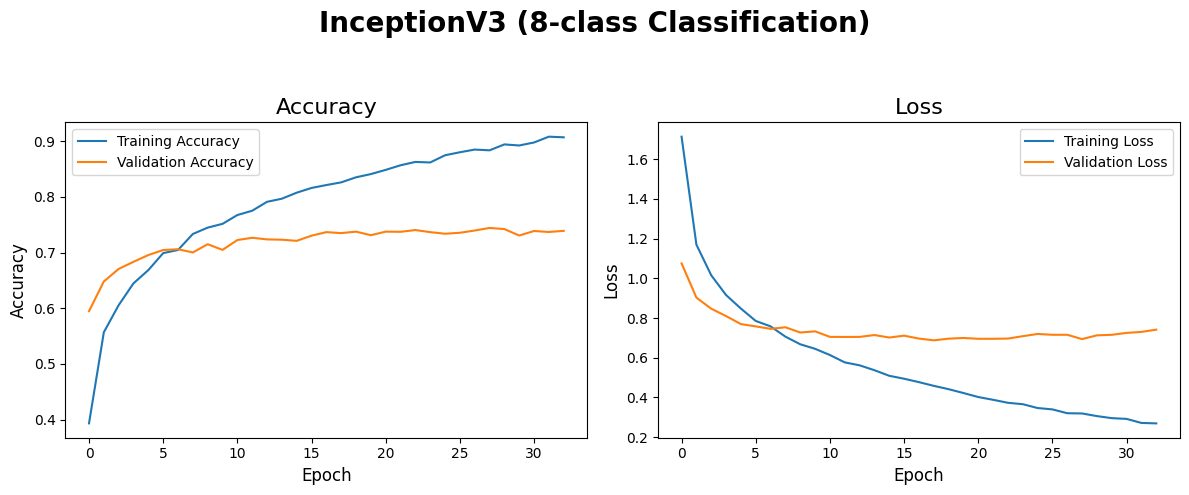

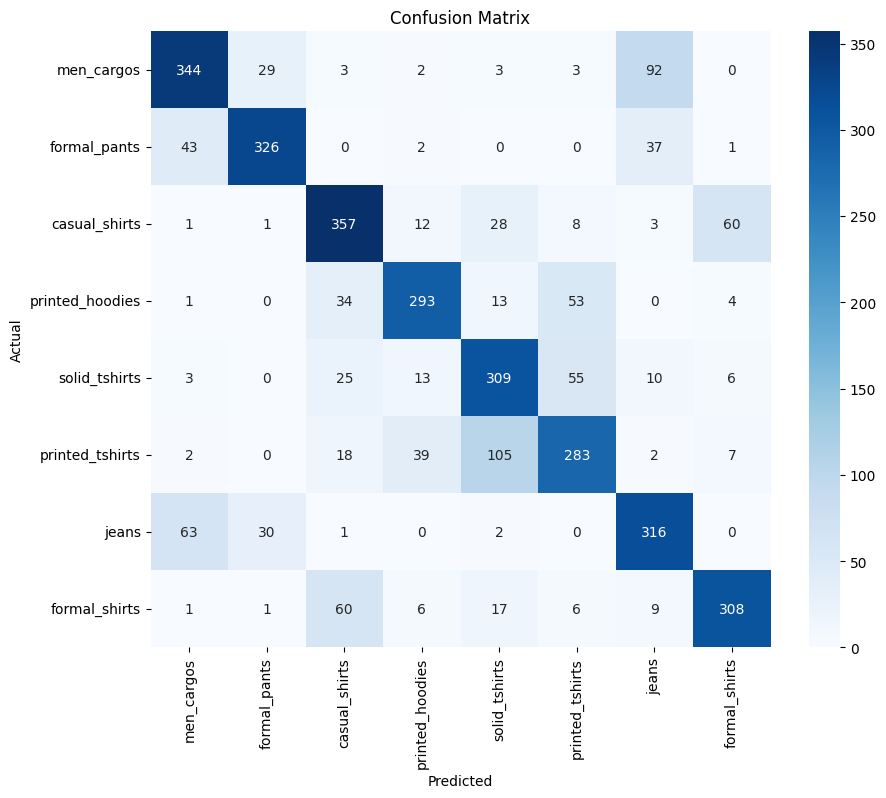

In [24]:
y_pred_prob = InceptionV3_model.predict(X_test)
y_pred_classes = np.argmax(y_pred_prob, axis=1)  

accuracy = accuracy_score(y_test, y_pred_classes)
print(f"Accuracy: {accuracy:.4f}")

plot_history(hist.history, "InceptionV3 (8-class Classification)")

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[idx_to_class[i] for i in range(8)],
            yticklabels=[idx_to_class[i] for i in range(8)])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [25]:
from tensorflow.keras.applications import Xception

base_model = Xception(weights='imagenet', include_top=False, input_shape=(128,128,3))
base_model.trainable = False  

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(8, activation='softmax')(x)  

Xception_model = Model(inputs=base_model.input, outputs=predictions)

Xception_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',  
    metrics=['accuracy']
)

Xception_model.summary()

hist = Xception_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=16,
    class_weight=class_weights,  
    callbacks=[early_stopping]
)

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 63, 63,    │        864 │ input_layer_8[0]… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_bn     │ (None, 63, 63,    │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_act    │ (None, 63, 63,    │          0 │ block1_conv1_bn[… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 61, 61,    │     18,432 │ block1_conv1_act… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_bn     │ (None, 61, 61,    │        256 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_act    │ (None, 61, 61,    │          0 │ block1_conv2_bn[… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1     │ (None, 61, 61,    │      8,768 │ block1_conv2_act… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1_bn  │ (None, 61, 61,    │        512 │ block2_sepconv1[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_act │ (None, 61, 61,    │          0 │ block2_sepconv1_… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2     │ (None, 61, 61,    │     17,536 │ block2_sepconv2_… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_bn  │ (None, 61, 61,    │        512 │ block2_sepconv2[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_96 (Conv2D)  │ (None, 31, 31,    │      8,192 │ block1_conv2_act… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 31, 31,    │          0 │ block2_sepconv2_… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 31, 31,    │        512 │ conv2d_96[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_9 (Add)         │ (None, 31, 31,    │          0 │ block2_pool[0][0… │
│                     │ 128)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_sepconv1_act │ (None, 31, 31,    │          0 │ add_9[0][0]     

 Total params: 21,124,784 (80.58 MB)

 Trainable params: 263,304 (1.00 MB)

...

321/324 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.3375 - loss: 1.7285

2026-02-03 08:57:33.478559: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-03 08:57:33.615168: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-03 08:57:34.288641: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-03 08:57:34.422553: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-03 08:57:35.137248: E external/local_xla/xla/stream_

324/324 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.3387 - loss: 1.7257

2026-02-03 08:57:53.161873: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-03 08:57:53.301110: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-03 08:57:53.983266: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-03 08:57:54.117372: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-03 08:57:54.821679: E external/local_xla/xla/stream_

324/324 ━━━━━━━━━━━━━━━━━━━━ 51s 113ms/step - accuracy: 0.3390 - loss: 1.7248 - val_accuracy: 0.6672 - val_loss: 0.9633
Epoch 2/50
324/324 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - accuracy: 0.6102 - loss: 1.0388 - val_accuracy: 0.7067 - val_loss: 0.8314
Epoch 3/50
324/324 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - accuracy: 0.6743 - loss: 0.8770 - val_accuracy: 0.7235 - val_loss: 0.7698
Epoch 4/50
324/324 ━━━━━━━━━━━━━━━━━━━━ 12s 36ms/step - accuracy: 0.6905 - loss: 0.8247 - val_accuracy: 0.7252 - val_loss: 0.7419
Epoch 5/50
324/324 ━━━━━━━━━━━━━━━━━━━━ 12s 36ms/step - accuracy: 0.7192 - loss: 0.7516 - val_accuracy: 0.7342 - val_loss: 0.7087
Epoch 6/50
324/324 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.7372 - loss: 0.7091 - val_accuracy: 0.7374 - val_loss: 0.6908
Epoch 7/50
324/324 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.7558 - loss: 0.6559 - val_accuracy: 0.7435 - val_loss: 0.6808
Epoch 8/50
324/324 ━━━━━━━━━━━━━━━━━━━━ 12s 36ms/step - accuracy: 0.7638 - loss: 0.6403 - val_accura

2026-02-03 09:05:49.322220: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-03 09:05:49.468878: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-03 09:05:50.387946: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-03 09:05:50.522883: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-03 09:05:51.293555: E external/local_xla/xla/stream_

107/108 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step

2026-02-03 09:06:04.271526: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-03 09:06:04.416201: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-03 09:06:05.233173: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-03 09:06:05.367597: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-03 09:06:06.124249: E external/local_xla/xla/stream_

108/108 ━━━━━━━━━━━━━━━━━━━━ 26s 139ms/step
Accuracy: 0.7678


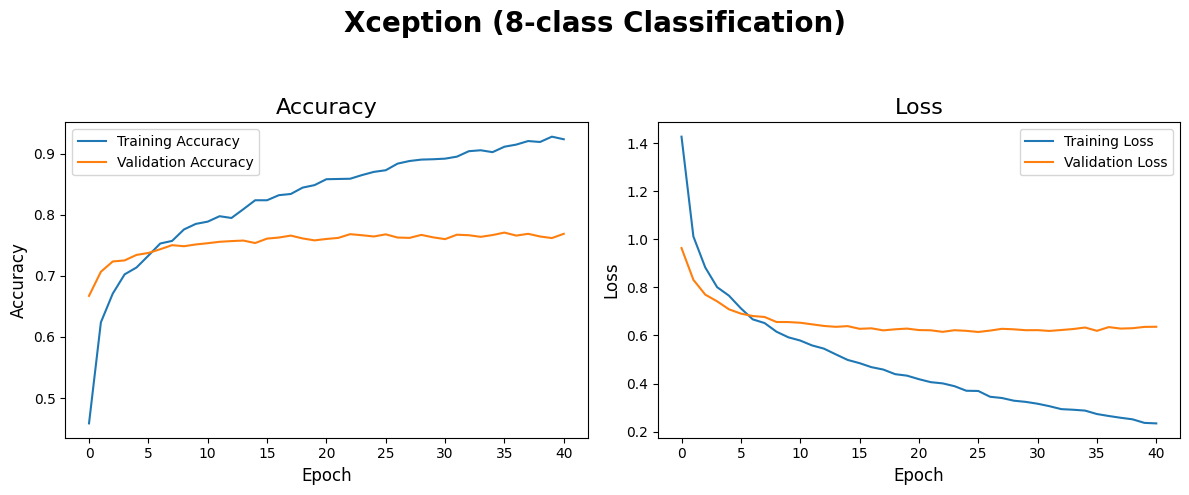

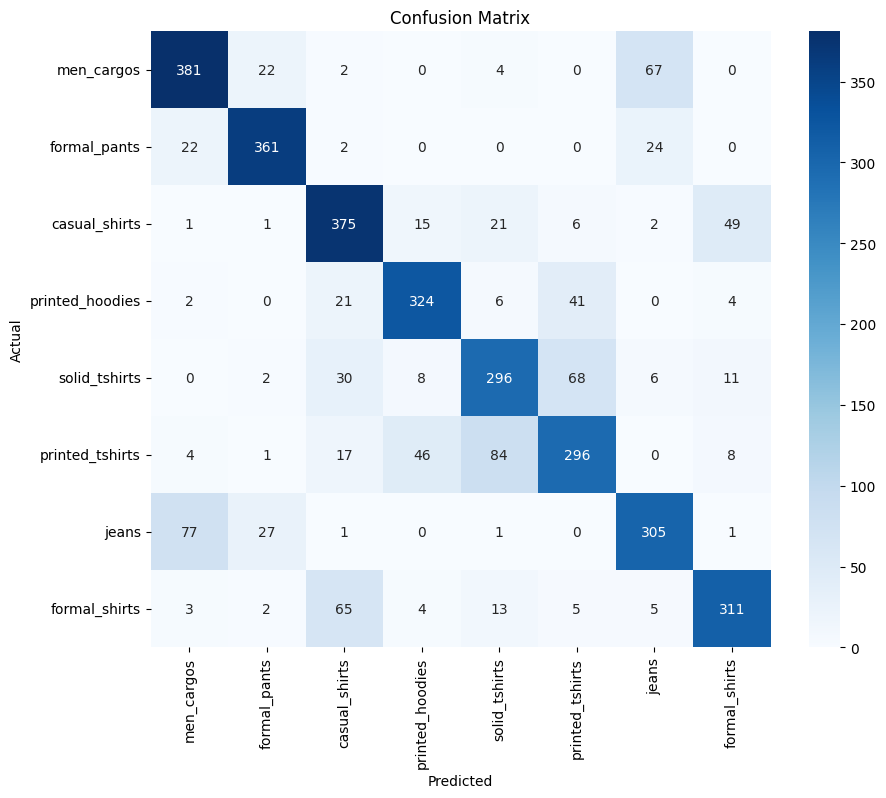

In [26]:
y_pred_prob = Xception_model.predict(X_test)
y_pred_classes = np.argmax(y_pred_prob, axis=1)  

accuracy = accuracy_score(y_test, y_pred_classes)
print(f"Accuracy: {accuracy:.4f}")

plot_history(hist.history, "Xception (8-class Classification)")

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[idx_to_class[i] for i in range(8)],
            yticklabels=[idx_to_class[i] for i in range(8)])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [27]:
from tensorflow.keras.applications import DenseNet121

base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(128,128,3))
base_model.trainable = False  

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(8, activation='softmax')(x)  

DenseNet121_model = Model(inputs=base_model.input, outputs=predictions)

DenseNet121_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',  
    metrics=['accuracy']
)

DenseNet121_model.summary()

hist = DenseNet121_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=16,
    class_weight=class_weights,  
    callbacks=[early_stopping]
)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 134, 134,  │          0 │ input_layer_9[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 64,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 64,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 66, 66,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 32, 32,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 32, 32,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 32, 32,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 32, 32,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 32, 32,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 32, 32,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 32, 32,    │     12,288 │ conv2_block2_0_r

 Total params: 7,169,736 (27.35 MB)

 Trainable params: 132,232 (516.53 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

Epoch 1/50
324/324 ━━━━━━━━━━━━━━━━━━━━ 65s 131ms/step - accuracy: 0.2385 - loss: 2.2614 - val_accuracy: 0.5896 - val_loss: 1.1401
Epoch 2/50
324/324 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.4959 - loss: 1.2687 - val_accuracy: 0.6487 - val_loss: 0.9430
Epoch 3/50
324/324 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.5892 - loss: 1.0509 - val_accuracy: 0.6864 - val_loss: 0.8381
Epoch 4/50
324/324 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.6191 - loss: 0.9812 - val_accuracy: 0.7125 - val_loss: 0.7745
Epoch 5/50
324/324 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.6489 - loss: 0.8948 - val_accuracy: 0.7391 - val_loss: 0.7134
Epoch 6/50
324/324 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.6868 - loss: 0.8217 - val_accuracy: 0.7487 - val_loss: 0.6915
Epoch 7/50
324/324 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.7052 - loss: 0.7625 - val_accuracy: 0.7606 - val_loss: 0.6586
Epoch 8/50
324/324 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.7148 - loss: 0.7445 -

108/108 ━━━━━━━━━━━━━━━━━━━━ 28s 143ms/step
Accuracy: 0.8119


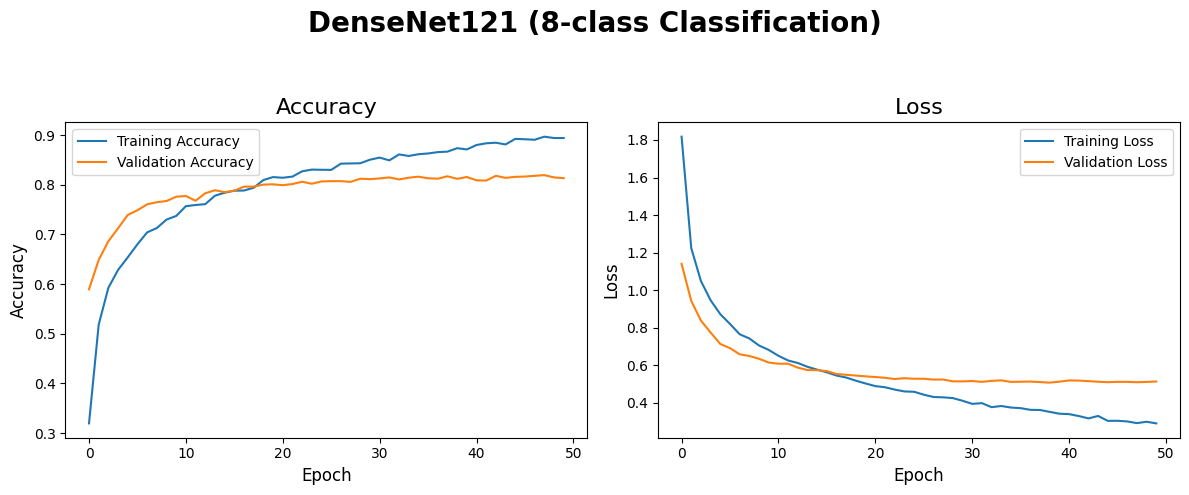

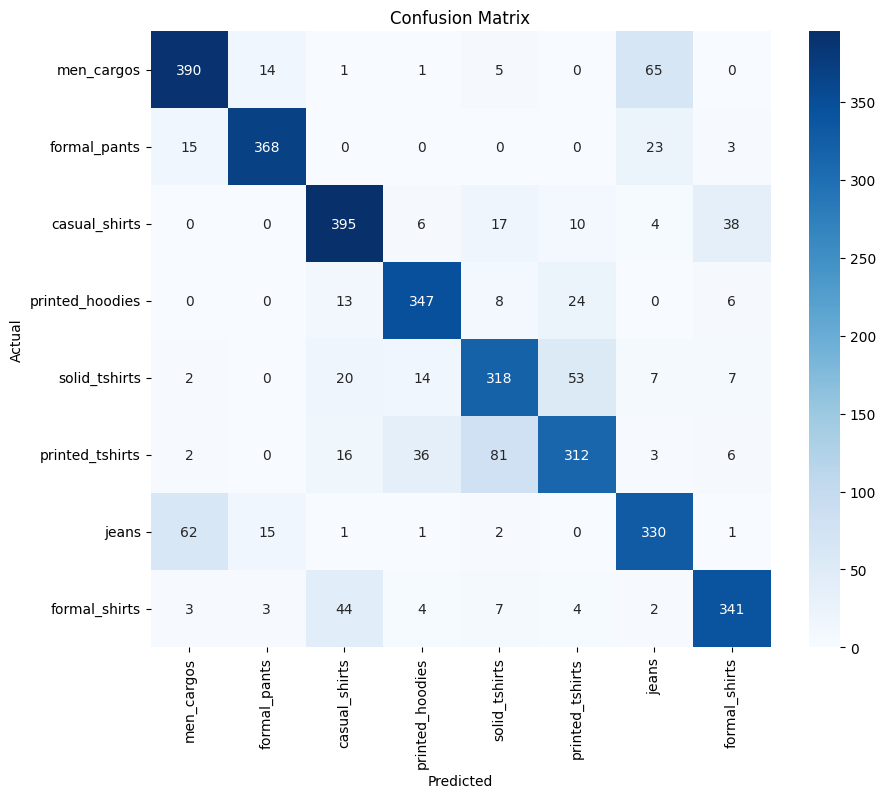

In [28]:
y_pred_prob = DenseNet121_model.predict(X_test)
y_pred_classes = np.argmax(y_pred_prob, axis=1)  

accuracy = accuracy_score(y_test, y_pred_classes)
print(f"Accuracy: {accuracy:.4f}")

plot_history(hist.history, "DenseNet121 (8-class Classification)")

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[idx_to_class[i] for i in range(8)],
            yticklabels=[idx_to_class[i] for i in range(8)])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# <div style="display: inline-block; padding: 20px 20px; border-radius: 15px; background: linear-gradient(135deg, #d8bfd8, #8b008b); box-shadow: 3px 3px 8px rgba(0, 0, 0, 0.2); font-size: 35px; font-family: Arial, sans-serif; color: #ffffff; text-align: center;">Comparative Study of DNN and Transfer Learning for Category Classification</div>

In [29]:
models = {
    "Single-Layer Perceptron": model_single,
    "DNN": model_dnn,
    "CNN": model_cnn,
    "MobileNetV2": v2_model,
    "MobileNetV3Small": v3_model,
    "ResNet50": ResNet50_model,
    "VGG16": VGG16_model,
    "InceptionV3": InceptionV3_model,
    "Xception": Xception_model,
    "DenseNet121": DenseNet121_model
}

results = []

for model_name, model in models.items():
    y_pred_prob = model.predict(X_test, verbose=0)
    y_pred_classes = np.argmax(y_pred_prob, axis=1)
    accuracy = accuracy_score(y_test, y_pred_classes)

    results.append({
        "Model": model_name,
        "Accuracy": accuracy
    })

results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)

print("\nResults\n")
display(results_df)


Results



,Model,Accuracy
9,DenseNet121,0.811884
3,MobileNetV2,0.811594
8,Xception,0.767826
7,InceptionV3,0.735072
6,VGG16,0.724928
2,CNN,0.655362
1,DNN,0.537101
5,ResNet50,0.470725
4,MobileNetV3Small,0.337101
0,Single-Layer Perceptron,0.203478


In [30]:
best_model_name = results_df.iloc[0]["Model"]
best_model_acc = results_df.iloc[0]["Accuracy"]

print(f"Best Model: {best_model_name} (Accuracy: {best_model_acc:.4f})")

Best Model: DenseNet121 (Accuracy: 0.8119)


<div style="display: inline-block; padding: 10px 15px; border-radius: 20px; background: linear-gradient(135deg, #ff7f50, #ff1493); box-shadow: 5px 5px 15px rgba(0, 0, 0, 0.3); font-size: 30px; font-family: 'Helvetica Neue', Arial, sans-serif; color: #ffffff; text-align: center; border: 2px solid #ffffff;">Thanks !</div><br><br>

<h3> Feel free to ask any questions and use the code freely! </h3><br>
<h3> If this helped you, improved performance, or if you want fine-tuning tips, please vote! It really helps a lot!! </h3><br>
<div style="text-align: center;">
    <a href="https://www.kaggle.com/lko9911" target="_blank" style="display: inline-block; background-color: #3a86ff; color: #fff; text-decoration: none; padding: 5px 10px; border-radius: 10px; margin: 15px; font-size: 25px;">Kaggle</a>
    <a href="https://github.com/lko9911" target="_blank" style="display: inline-block; background-color: #ff8c00; color: #ffffff; text-decoration: none; padding: 5px 20px; border-radius: 15px; margin: 15px; border: 2px solid #ff4500; font-size: 25px; font-family: 'Arial', sans-serif; font-weight: bold; transition: all 0.3s ease;">GitHub</a></div>